In [3]:
import pandas as pd
import plotly.express as px

In [4]:
import os
path = r'C:\Users\hp\Downloads'
files = [f for f in os.listdir(path) if f.startswith('Nassau Candy')]
print(files)

df = pd.read_csv(r'C:\Users\hp\Downloads\Nassau Candy Distributor.csv')

df.head()

['Nassau Candy Distributor.csv', 'Nassau Candy Distributor.xlsx']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [6]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [8]:
# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [9]:
# Remove invalid records
df = df[df["Sales"] > 0]
df = df[df["Cost"] >= 0]
df = df[df["Gross Profit"].notnull()]

In [10]:
# Handle missing values
df["Units"] = df["Units"].fillna(1)

In [11]:
# Clean text columns
df["Division"] = df["Division"].str.strip().str.title()
df["Product Name"] = df["Product Name"].str.strip()

In [12]:
# Gross Margin %
df["Gross Margin %"] = (df["Gross Profit"] / df["Sales"]) * 100

# Profit per Unit
df["Profit per Unit"] = df["Gross Profit"] / df["Units"]

# Contributions
total_sales = df["Sales"].sum()
total_profit = df["Gross Profit"].sum()

df["Revenue Contribution"] = df["Sales"] / total_sales
df["Profit Contribution"] = df["Gross Profit"] / total_profit

In [13]:
product_analysis = df.groupby("Product Name").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Gross Profit", "sum"),
    Avg_Margin=("Gross Margin %", "mean")
).reset_index()

product_analysis.head()

,Product Name,Total_Sales,Total_Profit,Avg_Margin
0,Everlasting Gobstopper,130.00,104.00,80.000000
1,Fizzy Lifting Drinks,78.75,47.25,60.000000
2,Fun Dip,12.00,4.80,40.000000
3,Hair Toffee,76.50,59.50,77.777778
4,Kazookles,1205.75,92.75,7.692308


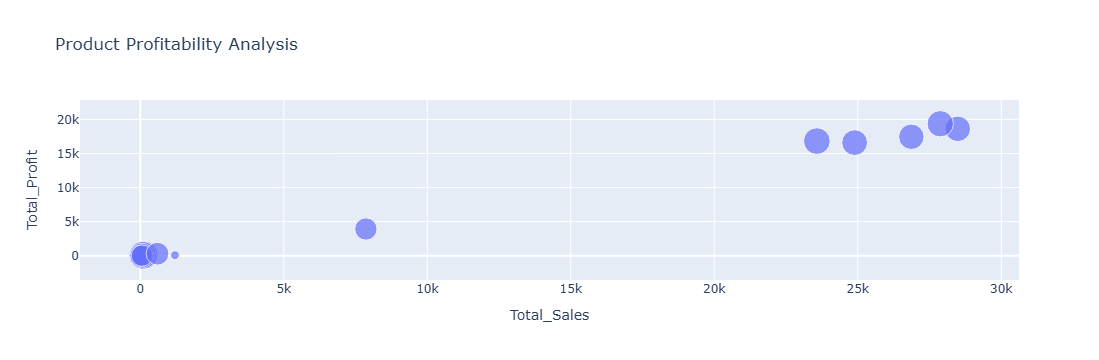

In [14]:
fig = px.scatter(
    product_analysis,
    x="Total_Sales",
    y="Total_Profit",
    size="Avg_Margin",
    hover_name="Product Name",
    title="Product Profitability Analysis"
)

fig.show()

In [15]:
# High profit & high margin
high_perf = product_analysis[
    (product_analysis["Total_Profit"] > product_analysis["Total_Profit"].median()) &
    (product_analysis["Avg_Margin"] > product_analysis["Avg_Margin"].median())
]

high_perf

,Product Name,Total_Sales,Total_Profit,Avg_Margin
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.666667
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.346705
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.444444


In [16]:
# High sales but low margin
low_margin = product_analysis[
    (product_analysis["Total_Sales"] > product_analysis["Total_Sales"].median()) &
    (product_analysis["Avg_Margin"] < product_analysis["Avg_Margin"].median())
]

low_margin

,Product Name,Total_Sales,Total_Profit,Avg_Margin
4,Kazookles,1205.75,92.75,7.692308
6,Lickable Wallpaper,7860.00,3930.00,50.000000


In [17]:
# Low performers
low_perf = product_analysis[
    (product_analysis["Total_Profit"] < product_analysis["Total_Profit"].median())
]

low_perf

,Product Name,Total_Sales,Total_Profit,Avg_Margin
1,Fizzy Lifting Drinks,78.75,47.25,60.000000
2,Fun Dip,12.00,4.80,40.000000
3,Hair Toffee,76.50,59.50,77.777778
4,Kazookles,1205.75,92.75,7.692308
5,Laffy Taffy,53.73,33.48,62.311558
7,Nerds,15.00,7.00,46.666667
8,SweeTARTS,61.50,28.70,46.666667


In [18]:
division_analysis = df.groupby("Division").agg(
    Revenue=("Sales", "sum"),
    Profit=("Gross Profit", "sum"),
    Avg_Margin=("Gross Margin %", "mean")
).reset_index()

division_analysis

,Division,Revenue,Profit,Avg_Margin
0,Chocolate,131692.90,88824.62,67.458162
1,Other,9663.25,4333.45,37.672457
2,Sugar,427.48,284.73,57.689001


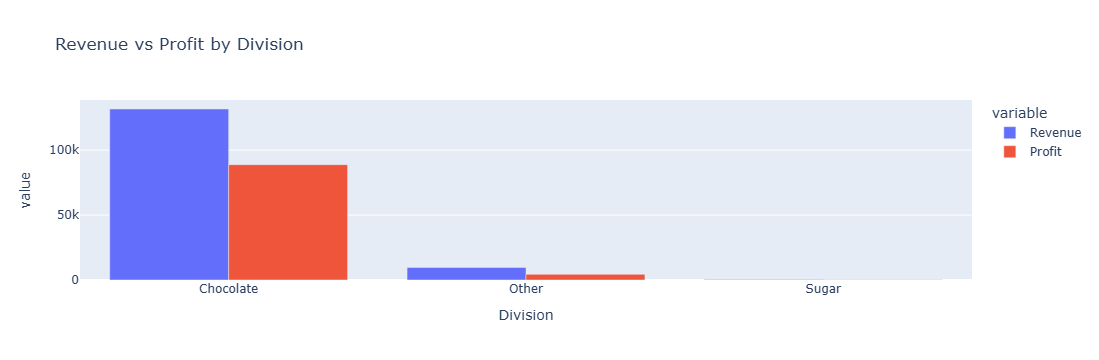

In [19]:
fig = px.bar(
    division_analysis,
    x="Division",
    y=["Revenue", "Profit"],
    barmode="group",
    title="Revenue vs Profit by Division"
)

fig.show()

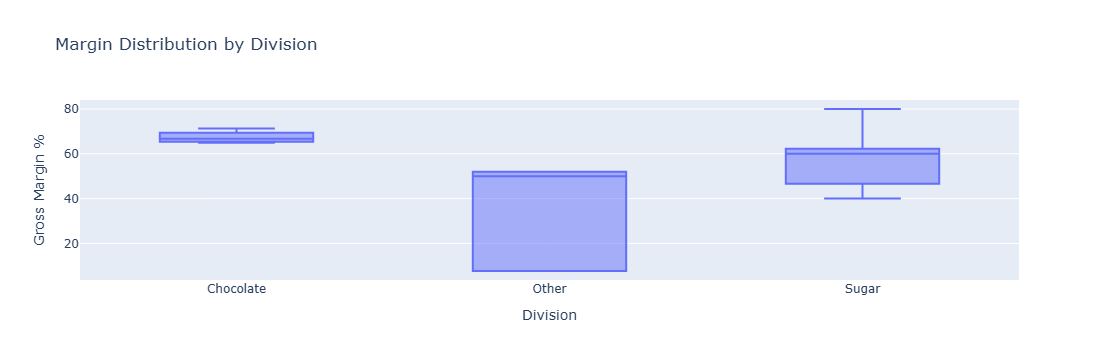

In [20]:
fig = px.box(
    df,
    x="Division",
    y="Gross Margin %",
    title="Margin Distribution by Division"
)

fig.show()

In [21]:
pareto = product_analysis.sort_values("Total_Profit", ascending=False)

pareto["Cumulative Profit"] = pareto["Total_Profit"].cumsum()
pareto["Cumulative %"] = pareto["Cumulative Profit"] / pareto["Total_Profit"].sum() * 100

pareto.head()

,Product Name,Total_Sales,Total_Profit,Avg_Margin,Cumulative Profit,Cumulative %
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.444444,19357.50,20.715882
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333,37967.70,40.632023
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077,55411.07,59.299454
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.346705,72231.02,77.299717
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.666667,88824.62,95.057747


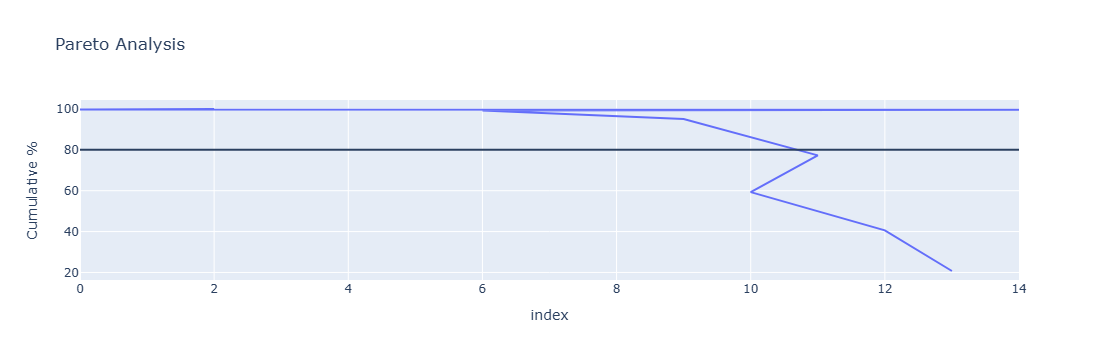

In [22]:
fig = px.line(
    pareto,
    y="Cumulative %",
    title="Pareto Analysis"
)

fig.add_hline(y=80)

fig.show()

In [23]:
top_80 = pareto[pareto["Cumulative %"] <= 80]

len(top_80)

4

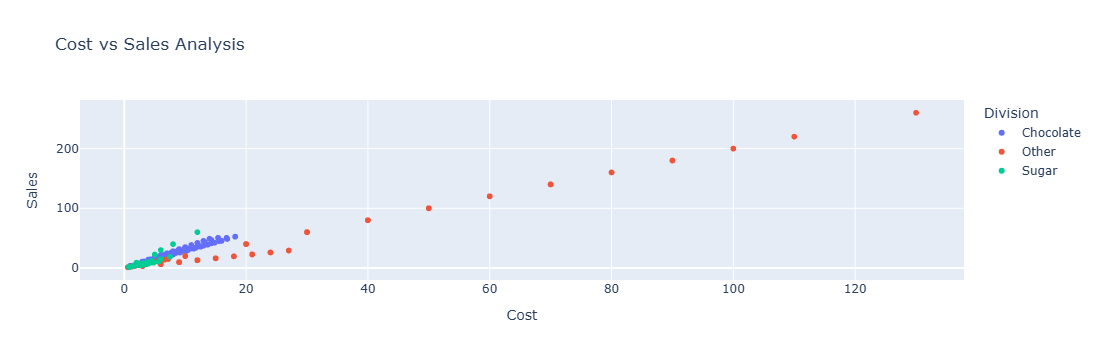

In [24]:
fig = px.scatter(
    df,
    x="Cost",
    y="Sales",
    color="Division",
    hover_data=["Product Name"],
    title="Cost vs Sales Analysis"
)

fig.show()

In [25]:
# Problem products
problem_products = df[
    (df["Cost"] > df["Cost"].median()) &
    (df["Gross Margin %"] < df["Gross Margin %"].median())
]

problem_products.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Gross Margin %,Profit per Unit,Revenue Contribution,Profit Contribution
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,65.333333,2.45,0.000079,0.000079
9,10,US-2021-167199-CHO-MIL-31000,2024-01-06,2026-07-03,Standard Class,167199,United States,Henderson,Kentucky,42420,...,CHO-MIL-31000,Wonka Bar - Milk Chocolate,13.00,4,8.44,4.56,64.923077,2.11,0.000092,0.000090
15,16,US-2021-105417-CHO-TRI-54000,2024-01-07,2026-07-05,Standard Class,105417,United States,Huntsville,Texas,77340,...,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,26.25,7,17.15,9.10,65.333333,2.45,0.000185,0.000184
17,18,US-2021-135405-CHO-TRI-54000,2024-01-09,2026-07-06,Standard Class,135405,United States,Laredo,Texas,78041,...,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,65.333333,2.45,0.000079,0.000079
23,24,US-2021-157147-CHO-MIL-31000,2024-01-13,2026-07-11,Standard Class,157147,United States,San Francisco,California,94109,...,CHO-MIL-31000,Wonka Bar - Milk Chocolate,16.25,5,10.55,5.70,64.923077,2.11,0.000115,0.000113


In [26]:
df["Month"] = df["Order Date"].dt.to_period("M")

volatility = df.groupby("Month")["Gross Margin %"].std().reset_index()

volatility

,Month,Gross Margin %
0,2024-01,5.912544
1,2024-02,8.649110
2,2024-03,9.076984
3,2024-04,5.839906
4,2024-05,7.639617
5,2024-06,6.815267
6,2024-07,8.331302
7,2024-08,5.774484
8,2024-09,5.589452
9,2024-10,5.926386


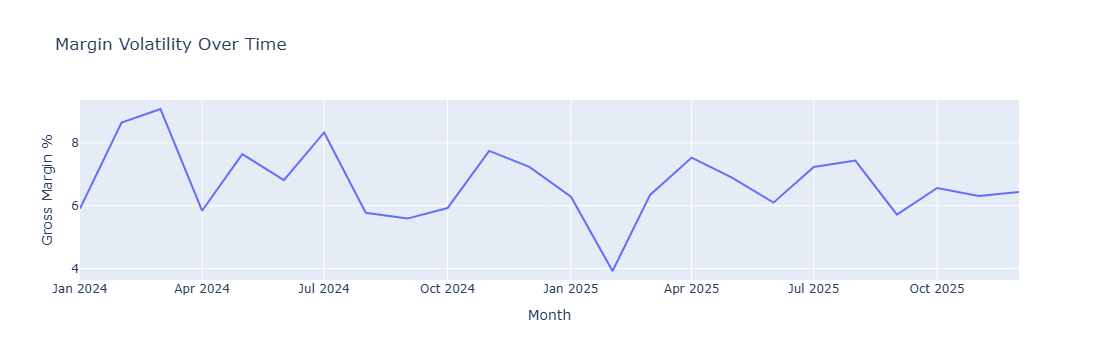

In [29]:
# Convert Period to the start of the month timestamp
volatility['Month'] = volatility['Month'].dt.to_timestamp()

fig = px.line(
    volatility,
    x="Month",
    y="Gross Margin %",
    title="Margin Volatility Over Time"
)

fig.show()